# Single Backtest Runner

This notebook orchestrates a single backtest run using the `ggTrader` orchestrator api. It supports flexible configuration and interactive visualization of performance results.

In [4]:
import sys
import os
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt

# Auto-reload custom modules
%load_ext autoreload
%autoreload 2

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.core.orchestrator import run_backtest_orchestrator

print("Environment initialized.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment initialized.


In [ ]:
# --- Configuration ---
CONSTANTS = {
    "SYMBOLS_FILE": os.path.join(os.getcwd(), "..", "data", "top_20_USD_2025-01-01_2025-12-31.json"),
    "INTERVAL": "4h",
    "START_DATE": "2025-01-01",
    "END_DATE": "2025-12-31",
    "START_CASH": 1000,
    "PORTFOLIO_SHARE": 0.10,
    "FEES": 0.004,
    "USE_MOVERS": 0,
    "SLIPPAGE": 0.003,
    "DEFAULT_PARAMS": {
        # entry
        "sar_acceleration": 0.02,
        "use_dmp_cross": False,
        "sar_maximum": 0.2,
        "adx_threshold": 25,
        "adx_length": 28,
        # exit
        "atr_multiplier": 0.01,
        "atr_length": 14,

    }
}

print("Configuration loaded.")

Configuration loaded.


In [7]:
# --- Run Backtest ---
# Set save_results=False for pure interactive work, or True to persist to results/ folder
results = run_backtest_orchestrator(
    config=CONSTANTS, 
    params=CONSTANTS["DEFAULT_PARAMS"], 
    save_results=False,
    show_progress=True
)

pf = results["portfolio"]
stats = results["stats"]

print("\nBacktest Complete.")

Loading data...


ValueError: Symbols file 'c:\Users\gkuep\PycharmProjects\ggTrader\notebooks\..\data\top_20_USD_2023-01-01_2025-12-31.json' not found or invalid.

In [ ]:
from tabulate import tabulate

# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))


Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2024-12-31 16:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      364 days 04:00:00
Start Value                 1000.00
End Value                   752.51
Total Return [%]            -24.75
Benchmark Return [%]        -34.58
Max Gross Exposure [%]      80.90
Total Fees Paid             186.92
Max Drawdown [%]            33.68
Max Drawdown Duration       346 days 20:00:00
Total Trades                543
Total Closed Trades         532
Total Open Trades           11
Open Trade PnL              -47.92
Win Rate [%]                22.37
Best Trade [%]              80.33
Worst Trade [%]             -48.10
Avg Winning Trade [%]       8.66
Avg Losing Trade [%]        -3.72
Avg Winning Trade Duration  7 days 06:13:06.554621848
Avg Losing Trade Duration   5 days 18:44:27.312348668
Profit Factor               0.70
Exp

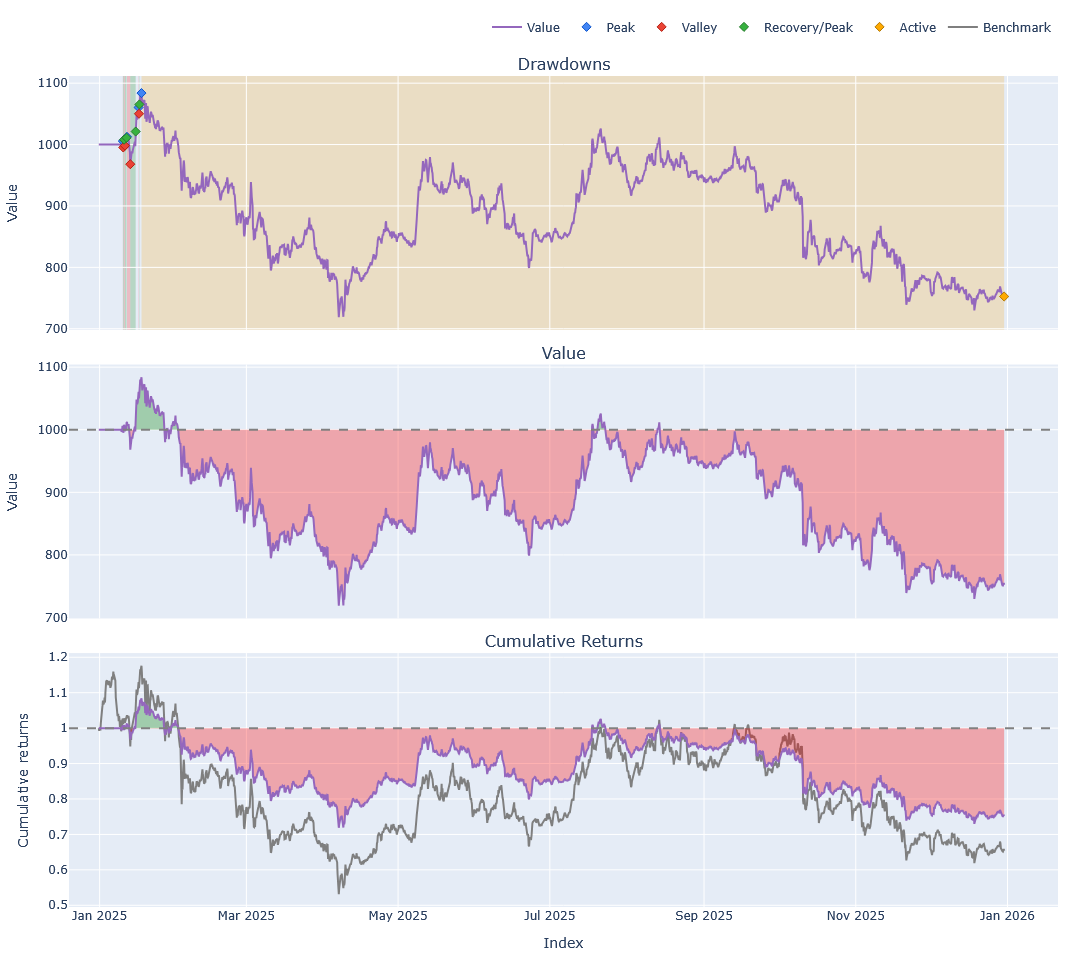

In [ ]:
pf.plot(subplots=['drawdowns','value','cum_returns' ]).show()

In [ ]:
# 1. Run backtest for just BTC
btc_pf = run_backtest_orchestrator(
    config={**CONSTANTS, "SYMBOLS": ["BTC"],"PORTFOLIO_SHARE": 1,"USE_CASH_SHARING": False,"group_by": False}, 
    params=CONSTANTS["DEFAULT_PARAMS"], 
    save_results=False,
    show_progress=True,
)["portfolio"]



Loading data...
Running backtest...


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from tabulate import tabulate

# --- Visualization ---
print("Global Portfolio Stats:")
# Convert stats to a DataFrame for a cleaner table view
stats_df = pf.stats().to_frame(name="Value").reset_index()

# 2. Format only the numbers to 2 decimals (ignoring dates and durations)
def format_values(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.2f}"
    return str(x)
stats_df["Value"] = stats_df["Value"].apply(format_values)

# 3. Print with tabulate (no floatfmt needed now because we formatted them in step 2)
print(tabulate(stats_df, headers=["Metric", "Value"], tablefmt="simple", numalign="right", showindex=False))

Global Portfolio Stats:
Metric                      Value
--------------------------  -------------------------
Start                       2024-12-31 16:00:00+00:00
End                         2025-12-30 16:00:00+00:00
Period                      364 days 04:00:00
Start Value                 1000.00
End Value                   752.51
Total Return [%]            -24.75
Benchmark Return [%]        -34.58
Max Gross Exposure [%]      80.90
Total Fees Paid             186.92
Max Drawdown [%]            33.68
Max Drawdown Duration       346 days 20:00:00
Total Trades                543
Total Closed Trades         532
Total Open Trades           11
Open Trade PnL              -47.92
Win Rate [%]                22.37
Best Trade [%]              80.33
Worst Trade [%]             -48.10
Avg Winning Trade [%]       8.66
Avg Losing Trade [%]        -3.72
Avg Winning Trade Duration  7 days 06:13:06.554621848
Avg Losing Trade Duration   5 days 18:44:27.312348668
Profit Factor               0.70
Exp

In [ ]:
# 2. Plot including PnL subplots
# This will show the BTC price, markers, and cumulative returns
btc_pf.iloc[0].plot().show()